In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

import os
import ast
import json

Here we are gonna make the different figures that's are included in the paper.

1. First, we are gonna make the figures related with the performance results of the models. That is, figures that showns how are the fidelities along different models, grid sizes of dataset, and with/without post-processing error correction

In [2]:
# Read fidelity data from CSV with and without post-processing correction
df = pd.read_csv('dataframe/fidelity_test.csv')

# Fidelity keys
fids_label = {
    0: "fid_01",
    1: "fid_025",
    2: "fid_05",
    3: "fid_10"
}

fids_color = {
    0: "red",
    1: "blue",
    2: "green",
    3: "gold"
}

fids_delta = {
    0: 0.1,
    1: 0.25,
    2: 0.5,
    3: 1.0
}

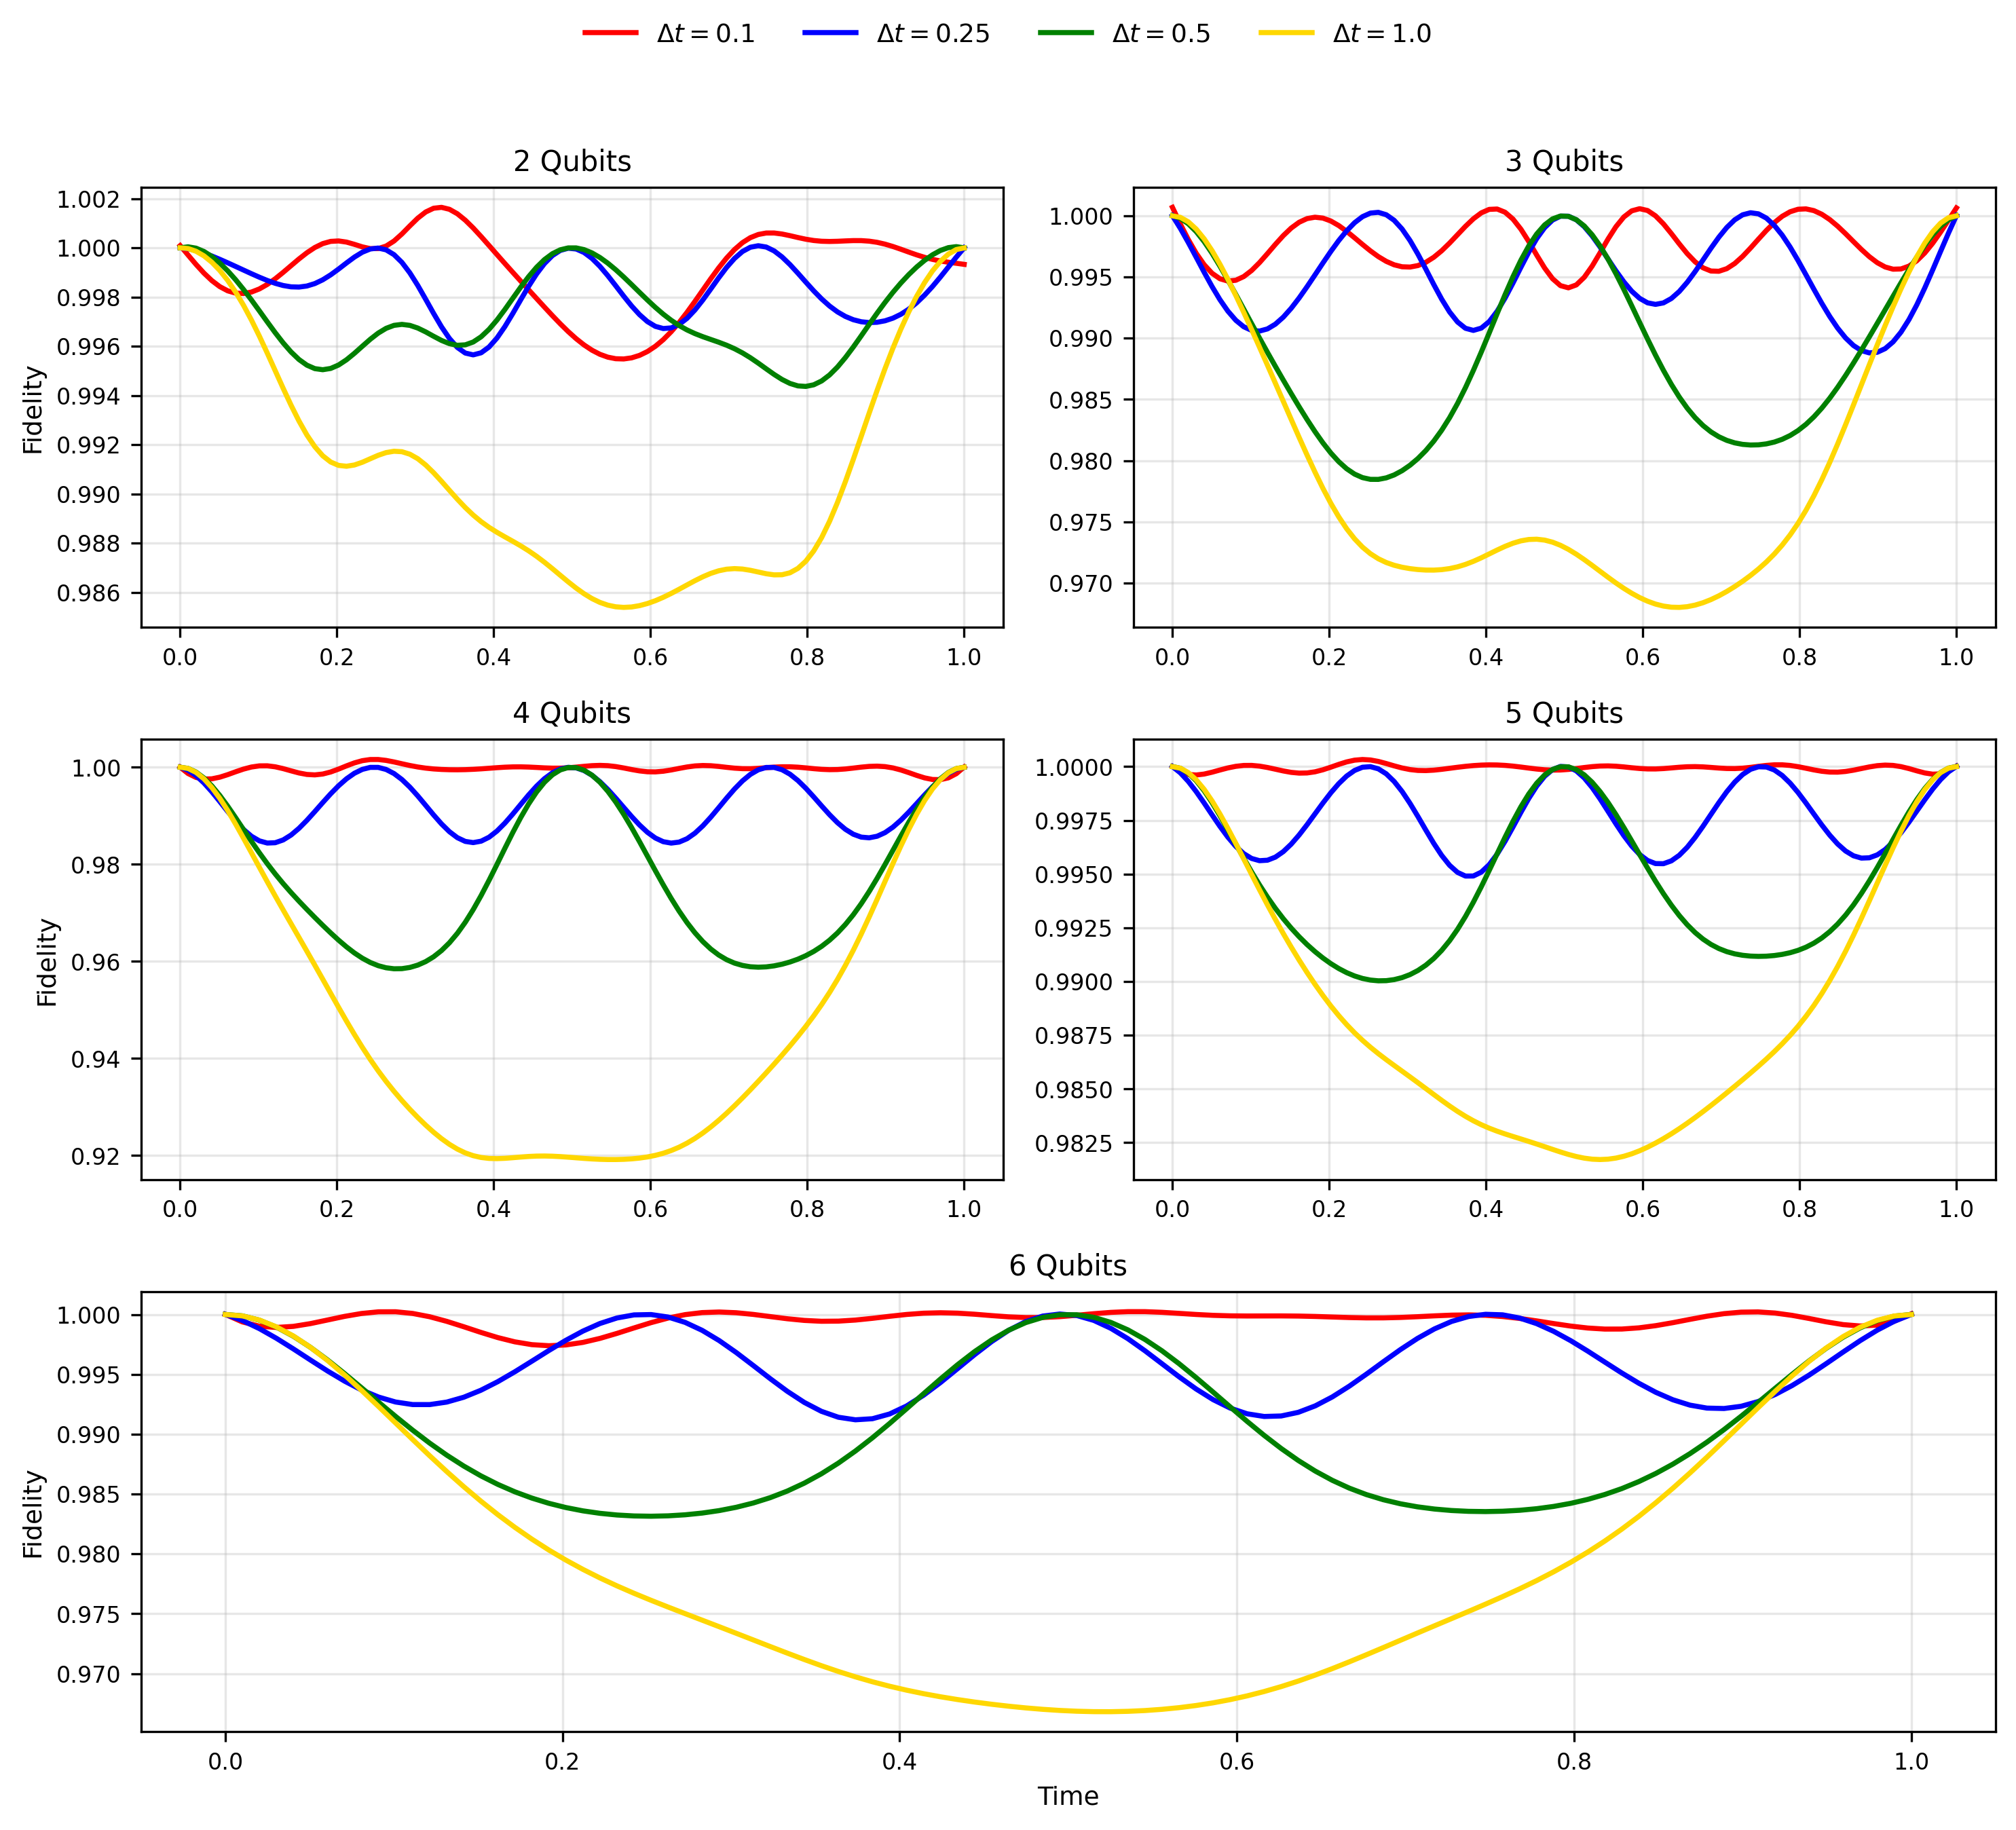

In [3]:
# General settings for the plot
cols = 2
n_qubits = 5                 # 2 → 6 qubits
rows = (n_qubits + cols - 1) // cols

fig = plt.figure(figsize=(cols * 5, rows * 3), dpi=300)
gs = gridspec.GridSpec(rows, cols, figure=fig)
df_without = df[df["close_U"] == False]

os.makedirs("figures", exist_ok=True)

axes = []

# Axis creation
for idx in range(n_qubits):
    if idx == n_qubits - 1:
        # Último subplot (6 qubits) ocupa ambas columnas
        ax = fig.add_subplot(gs[idx // cols, :])
    else:
        ax = fig.add_subplot(gs[idx // cols, idx % cols])
    axes.append(ax)

# Plot
for idx, ax in enumerate(axes):

    for f_ in range(4):
        raw = df_without[fids_label[f_]].to_numpy()[idx]

        fidelity = np.fromstring(
            raw.strip("[]"),
            sep="," if "," in raw else " "
        )

        times = np.linspace(0, 1, len(fidelity))

        label = rf"$\Delta t = {fids_delta[f_]}$" if idx == 0 else None

        ax.plot(
            times,
            fidelity,
            linewidth=1.8,
            color=fids_color[f_],
            label=label
        )

    ax.set_title(f"{idx + 2} Qubits", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

    if idx // cols == rows - 1:
        ax.set_xlabel("Time", fontsize=9)
    if idx % cols == 0:
        ax.set_ylabel("Fidelity", fontsize=9)

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    frameon=False
)

# Save figure
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    "figures/fidelity_qubits_2to6-without.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

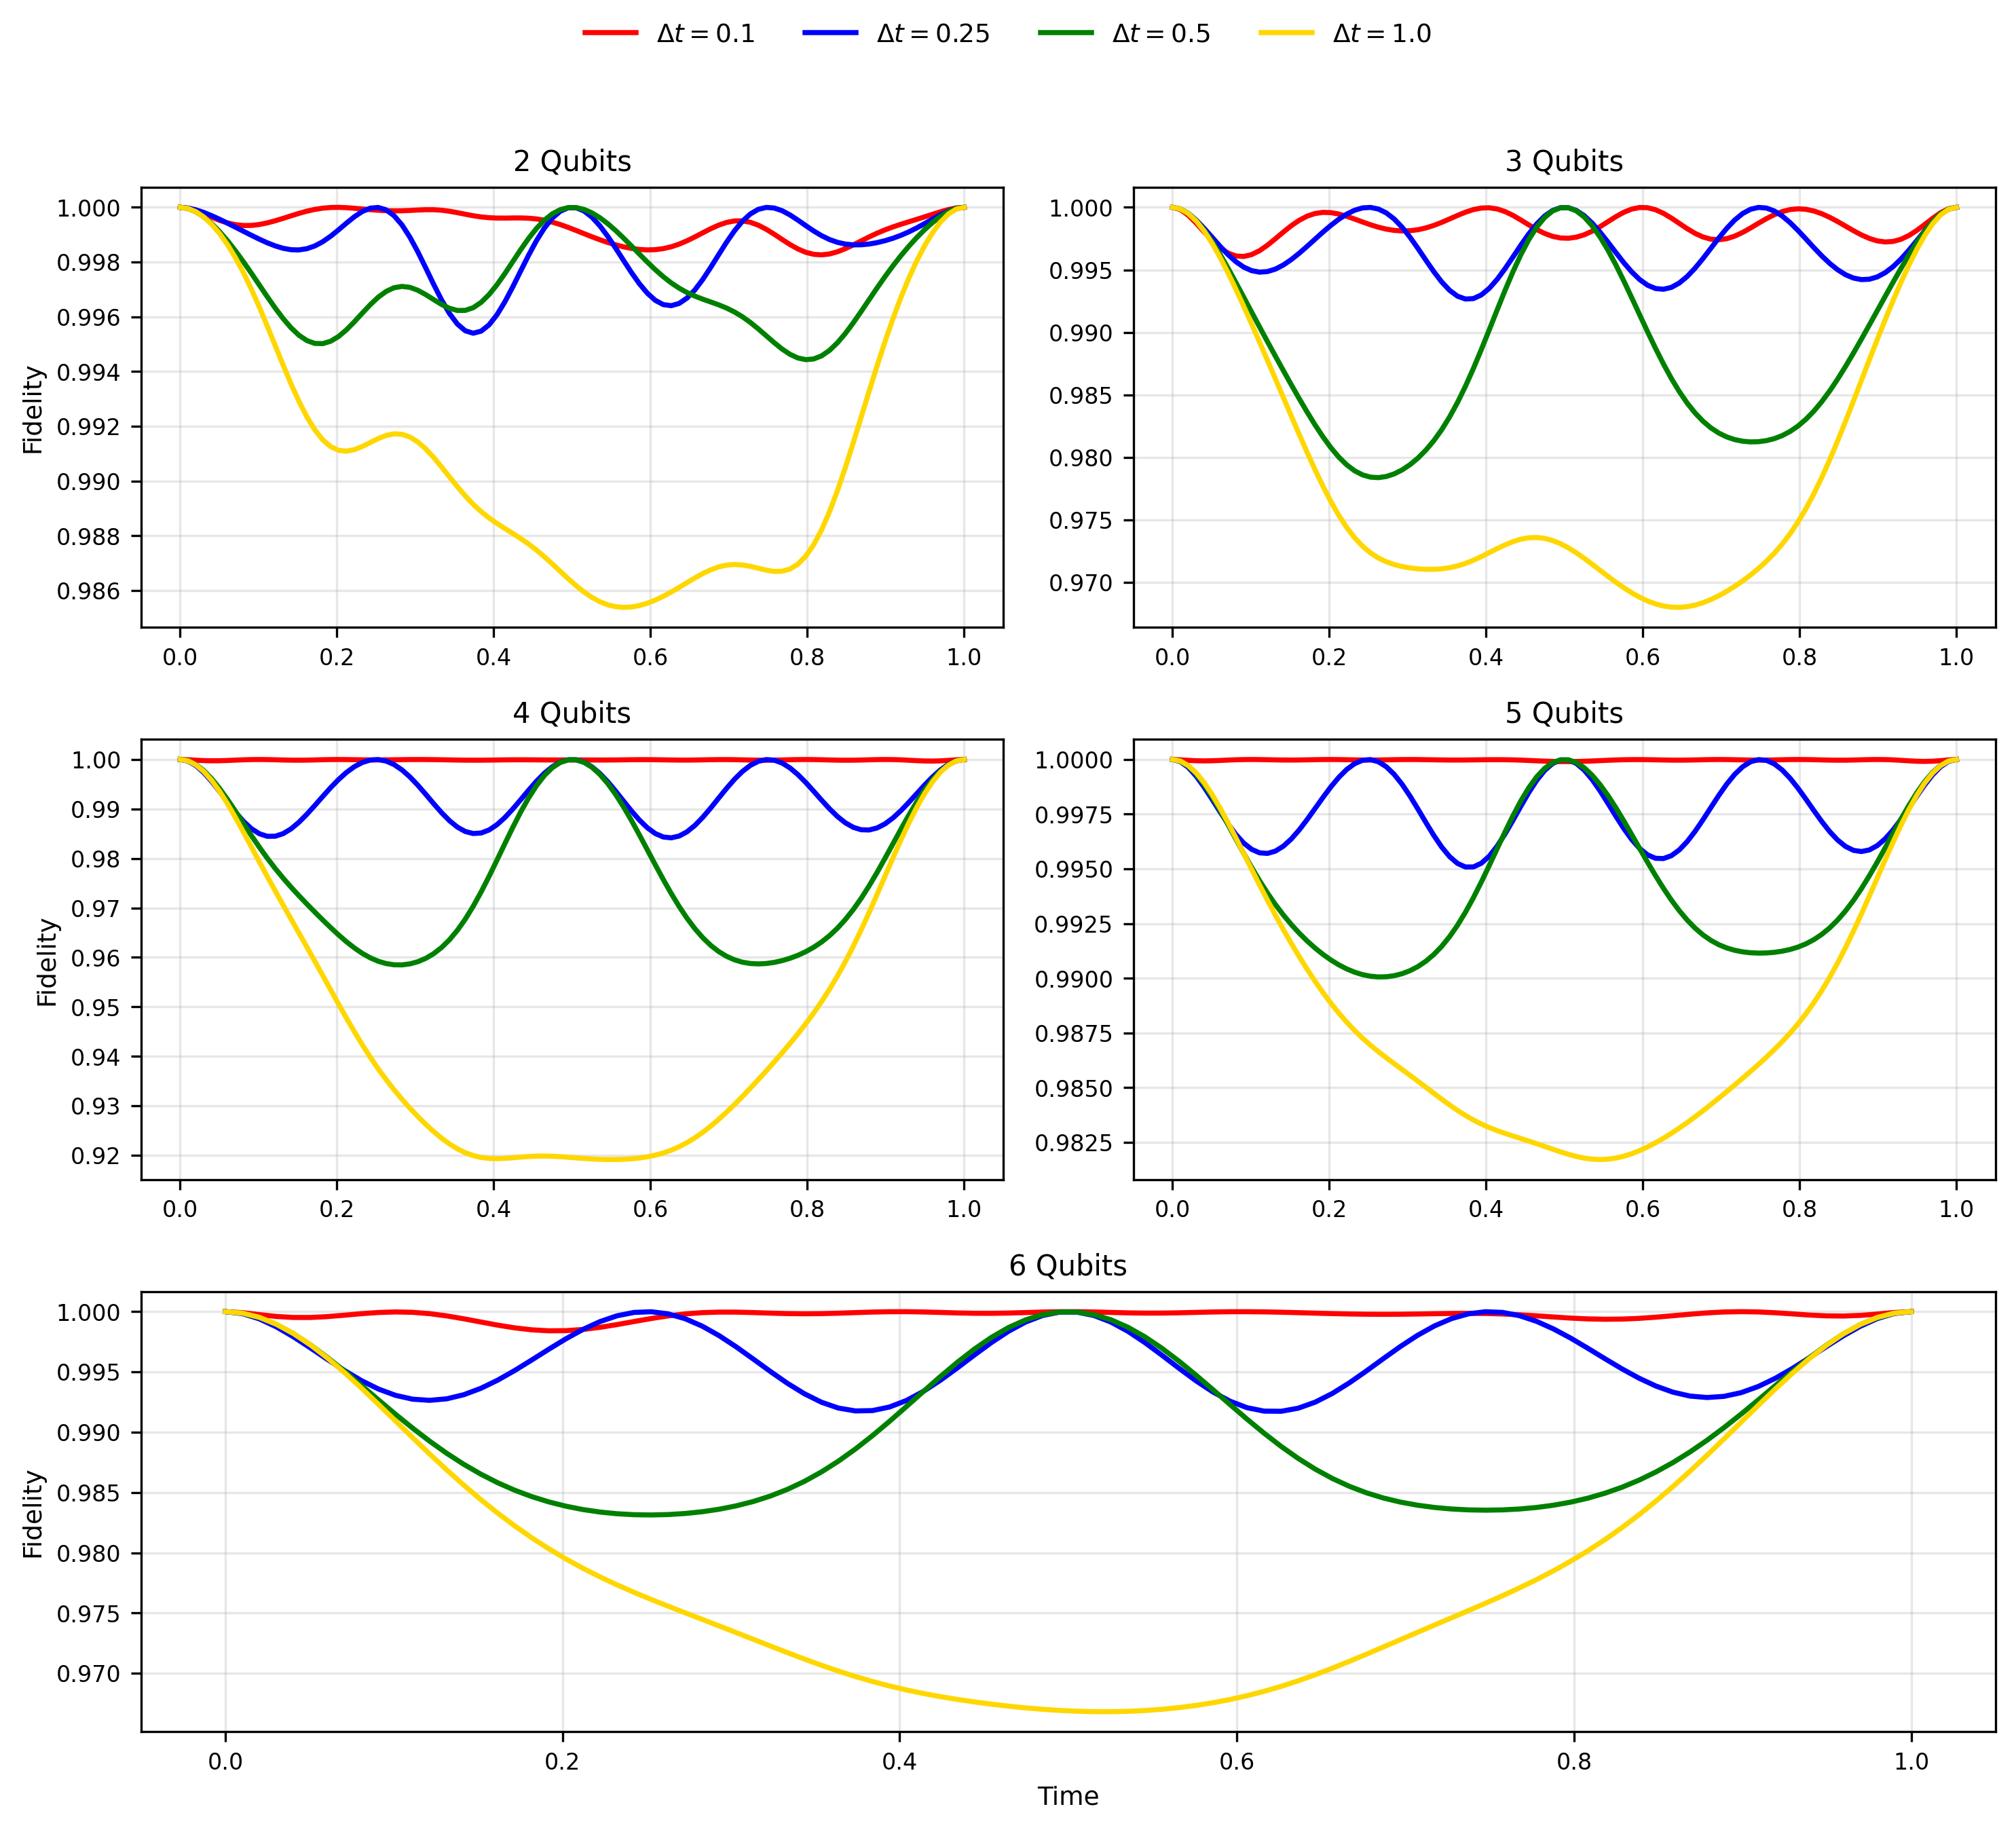

In [4]:
# General settings for the plot
cols = 2
n_qubits = 5                 # 2 → 6 qubits
rows = (n_qubits + cols - 1) // cols

fig = plt.figure(figsize=(cols * 5, rows * 3), dpi=300)
gs = gridspec.GridSpec(rows, cols, figure=fig)
df_with = df[df["close_U"] == True]

os.makedirs("figures", exist_ok=True)

axes = []

# Axis creation
for idx in range(n_qubits):
    if idx == n_qubits - 1:
        # Último subplot (6 qubits) ocupa ambas columnas
        ax = fig.add_subplot(gs[idx // cols, :])
    else:
        ax = fig.add_subplot(gs[idx // cols, idx % cols])
    axes.append(ax)

# Plot
for idx, ax in enumerate(axes):

    for f_ in range(4):
        raw = df_with[fids_label[f_]].to_numpy()[idx]

        fidelity = np.fromstring(
            raw.strip("[]"),
            sep="," if "," in raw else " "
        )

        times = np.linspace(0, 1, len(fidelity))

        label = rf"$\Delta t = {fids_delta[f_]}$" if idx == 0 else None

        ax.plot(
            times,
            fidelity,
            linewidth=1.8,
            color=fids_color[f_],
            label=label
        )

    ax.set_title(f"{idx + 2} Qubits", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

    if idx // cols == rows - 1:
        ax.set_xlabel("Time", fontsize=9)
    if idx % cols == 0:
        ax.set_ylabel("Fidelity", fontsize=9)

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    frameon=False
)

# Save figure
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    "figures/fidelity_qubits_2to6-with.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

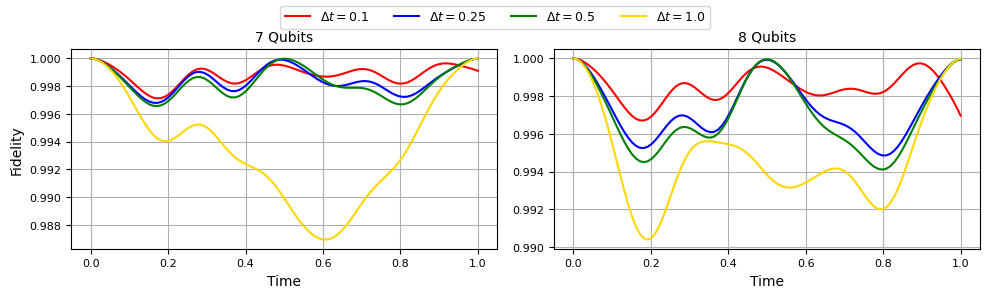

In [5]:
# Second plot of fidelities - for 7 and 8 qubits - using magnus
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)
times = np.linspace(0, 1, 100)
df_magnus = df[df["method"] == "magnus"]

for idx in [0, 1]:
    ax = axes[idx]

    for f_ in range(4):
        fidelity = df_magnus[fids_label[f_]].to_numpy()[idx]
        fidelity = np.fromstring(fidelity.strip('[]'), sep=' ')
        ax.plot(times, fidelity, color=fids_color[f_], label=r"$\Delta t = $" + str(fids_delta[f_]))

    ax.set_title(f"{idx + 7} Qubits", fontsize=10)  # idx+2 = número de qubits
    ax.grid(True)
    ax.set_xlabel("Time")
    if idx == 0:
        ax.set_ylabel("Fidelity")
    ax.tick_params(labelsize=8)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=9)

# Layout y guardado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figures/fidelity_qubits_7and8-magnus.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

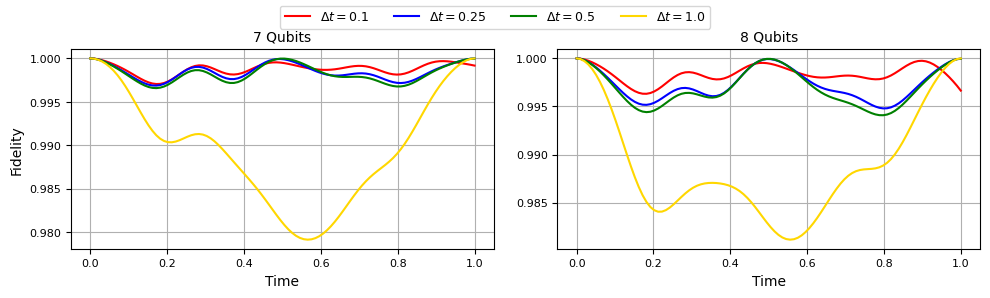

In [6]:
# Second plot of fidelities - for 7 and 8 qubits - using trotter
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)
times = np.linspace(0, 1, 100)
df_trotter = df[df["method"] == "trotter"]

for idx in [0, 1]:
    ax = axes[idx]

    for f_ in range(4):
        fidelity = df_trotter[fids_label[f_]].to_numpy()[idx]
        fidelity = np.fromstring(fidelity.strip('[]'), sep=' ')
        ax.plot(times, fidelity, color=fids_color[f_], label=r"$\Delta t = $" + str(fids_delta[f_]))

    ax.set_title(f"{idx + 7} Qubits", fontsize=10)  # idx+2 = número de qubits
    ax.grid(True)
    ax.set_xlabel("Time")
    if idx == 0:
        ax.set_ylabel("Fidelity")
    ax.tick_params(labelsize=8)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=9)

# Layout y guardado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figures/fidelity_qubits_7and8-trotter.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

2. Now, generates the figures related with loss training variation during training stage

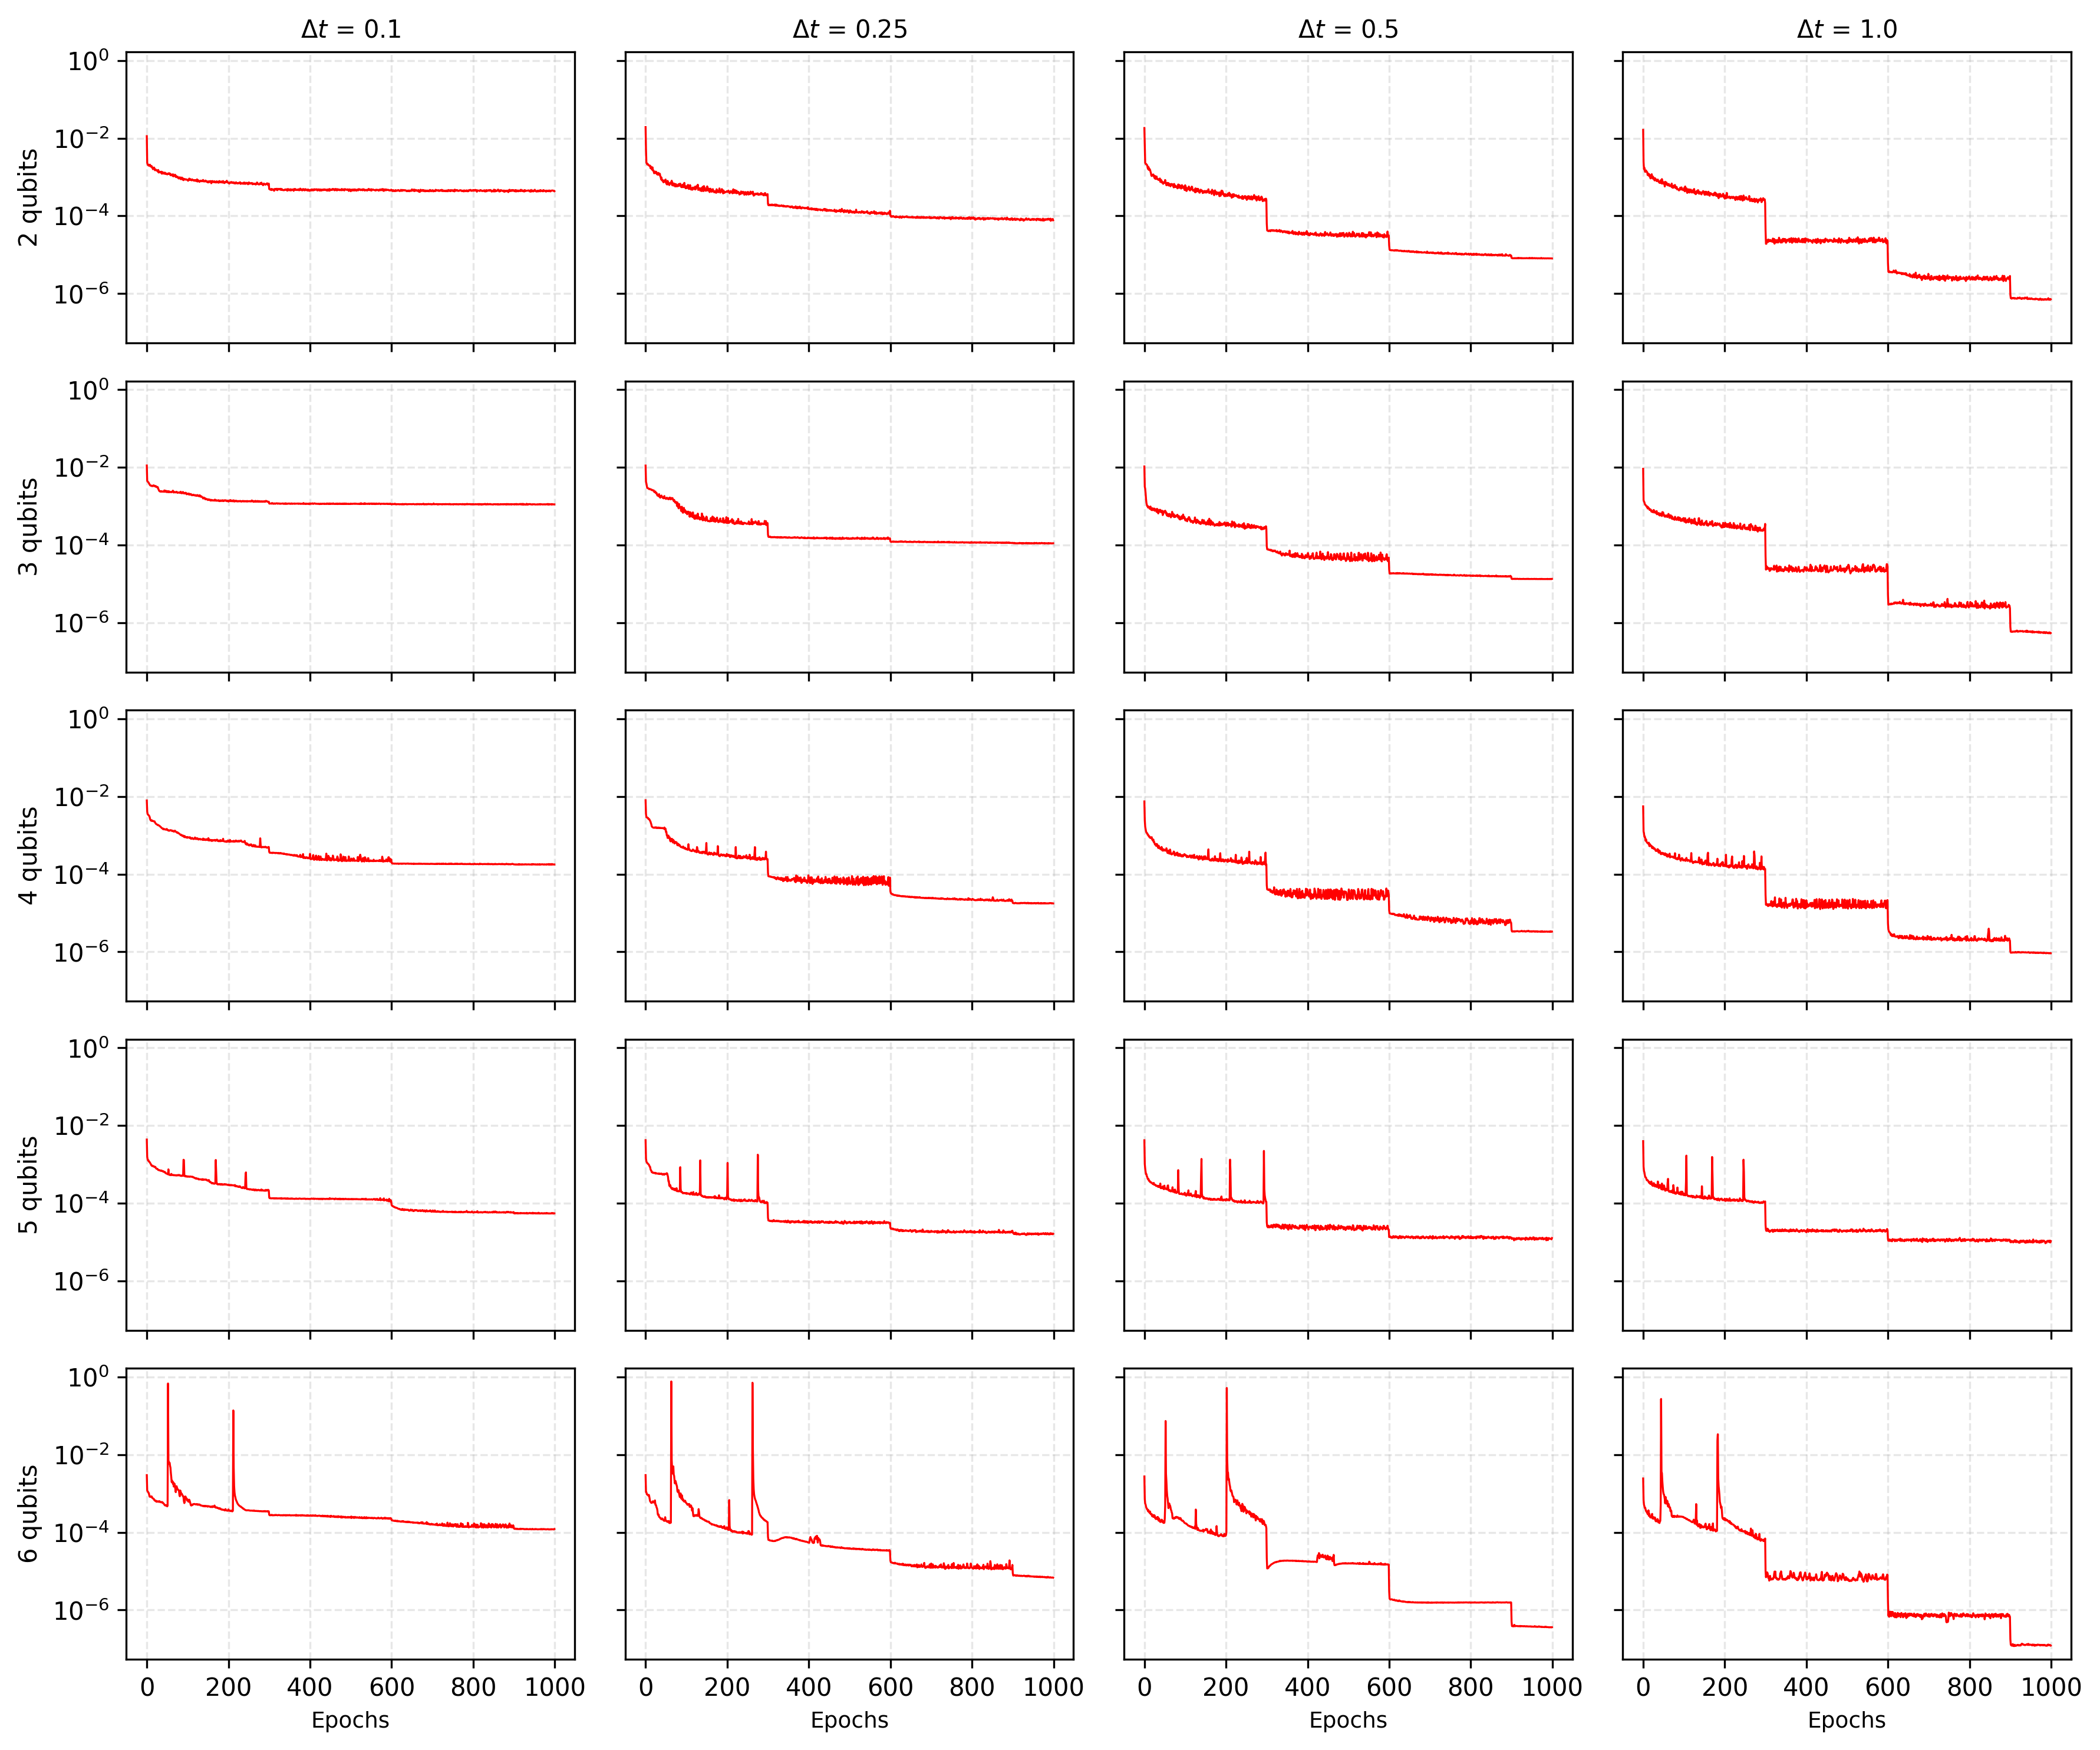

In [7]:
# ---------------------------------------------------------------------------------------- #
# Make the plot of losses function along the different models
def read_loss(N = 2, dt = 0.1, method = None):
    if method is None:
        df = pd.read_csv(f"data_loss/full-loss/dataloss-model{N}-delta_t{dt}.csv")
    else:
        df = pd.read_csv(f"data_loss/full-loss/dataloss-model{N}-delta_t{dt}-{method}.csv")

    train   = df["train_loss"].to_numpy()
    return train

# Define the different parameters of the models
Ns  = [n for n in range(2, 7)]
dts = [0.1, 0.25, 0.5, 1.0]

rows = len(Ns)
cols = len(dts)

# Plot the losses
# plt.clf()

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2), sharex=True, sharey=True, dpi=300)
# plt.subplots_adjust(hspace=0.25, wspace=0.2)

for i in range(rows):
    for j in range(cols):
        train = read_loss(N=Ns[i], dt=dts[j])
        epochs = np.arange(1000)

        ax = axes[i, j]
        ax.plot(train, color="red", linewidth=0.8)
        ax.set_yscale("log")
        ax.grid(True, linestyle='--', alpha=0.3)

        # Etiqueta de columna (arriba)
        if i == 0:
            ax.set_title(f"$\\Delta t$ = {dts[j]}", fontsize=10)

        # Etiqueta de fila (izquierda)
        if j == 0:
            ax.set_ylabel(f"{Ns[i]} qubits", fontsize=10)

        # Solo última fila con etiquetas en X
        if i == rows - 1:
            ax.set_xlabel("Epochs", fontsize=9)
        # else:
            # ax.set_xticklabels([])

        # Solo primera columna con etiquetas en Y
        # if j > 0:
            # ax.set_yticklabels([])

plt.tight_layout()
plt.savefig("figures/loss_variation_2to6.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

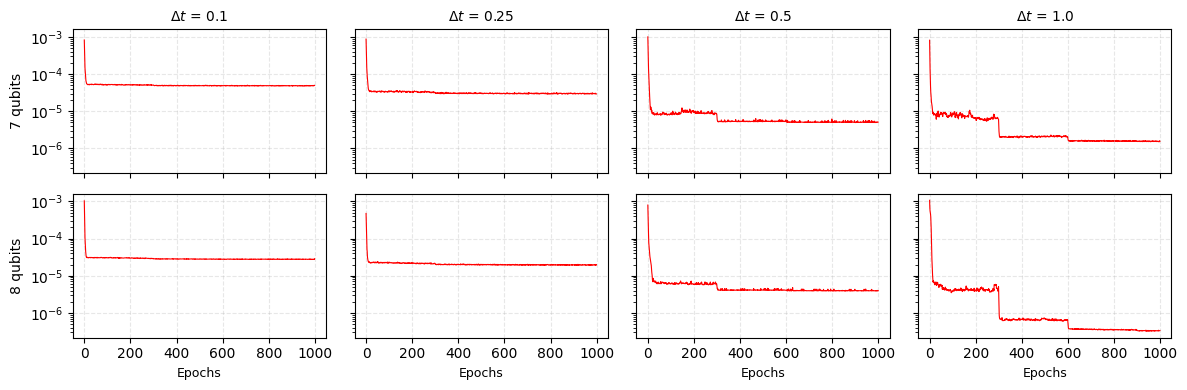

In [8]:
# Define the different parameters of the models
Ns  = [7, 8]
dts = [0.1, 0.25, 0.5, 1.0]
method = "trotter"

rows = len(Ns)
cols = len(dts)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.25, wspace=0.2)

for i in range(rows):
    for j in range(cols):
        train = read_loss(N=Ns[i], dt=dts[j], method=method)
        epochs = np.arange(1000)

        ax = axes[i, j]
        ax.plot(train, color="red", linewidth=0.8)
        ax.set_yscale("log")
        ax.grid(True, linestyle='--', alpha=0.3)

        # Etiqueta de columna (arriba)
        if i == 0:
            ax.set_title(f"$\\Delta t$ = {dts[j]}", fontsize=10)

        # Etiqueta de fila (izquierda)
        if j == 0:
            ax.set_ylabel(f"{Ns[i]} qubits", fontsize=10)

        # Solo última fila con etiquetas en X
        if i == rows - 1:
            ax.set_xlabel("Epochs", fontsize=9)
        # else:
            # ax.set_xticklabels([])

        # Solo primera columna con etiquetas en Y
        # if j > 0:
            # ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(f"figures/loss_variation_7and8-{method}.pdf", dpi=300, bbox_inches='tight')

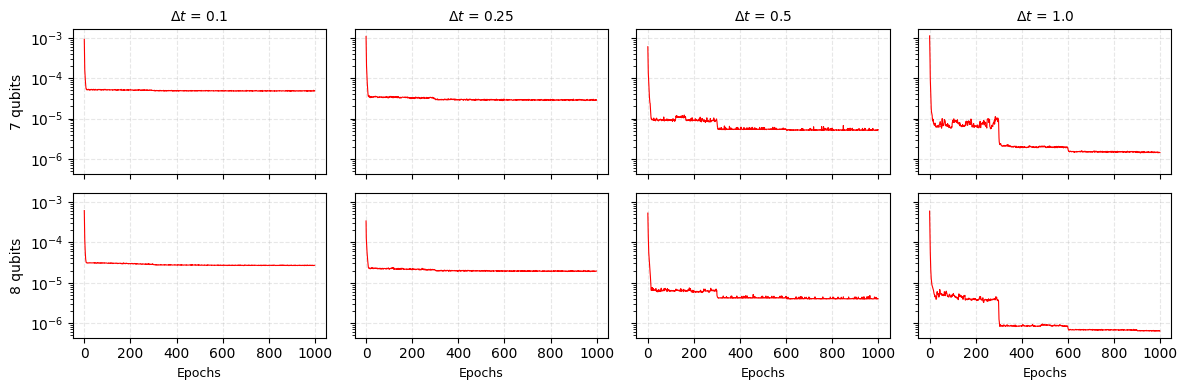

In [9]:
# Define the different parameters of the models
Ns  = [7, 8]
dts = [0.1, 0.25, 0.5, 1.0]
method = "magnus"

rows = len(Ns)
cols = len(dts)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.25, wspace=0.2)

for i in range(rows):
    for j in range(cols):
        train = read_loss(N=Ns[i], dt=dts[j], method=method)
        epochs = np.arange(1000)

        ax = axes[i, j]
        ax.plot(train, color="red", linewidth=0.8)
        ax.set_yscale("log")
        ax.grid(True, linestyle='--', alpha=0.3)

        # Etiqueta de columna (arriba)
        if i == 0:
            ax.set_title(f"$\\Delta t$ = {dts[j]}", fontsize=10)

        # Etiqueta de fila (izquierda)
        if j == 0:
            ax.set_ylabel(f"{Ns[i]} qubits", fontsize=10)

        # Solo última fila con etiquetas en X
        if i == rows - 1:
            ax.set_xlabel("Epochs", fontsize=9)
        # else:
            # ax.set_xticklabels([])

        # Solo primera columna con etiquetas en Y
        # if j > 0:
            # ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(f"figures/loss_variation_7and8-{method}.pdf", dpi=300, bbox_inches='tight')

3. The plot tha shown how increases the number of free parameters along with the size of the Hilbert space with more qubits

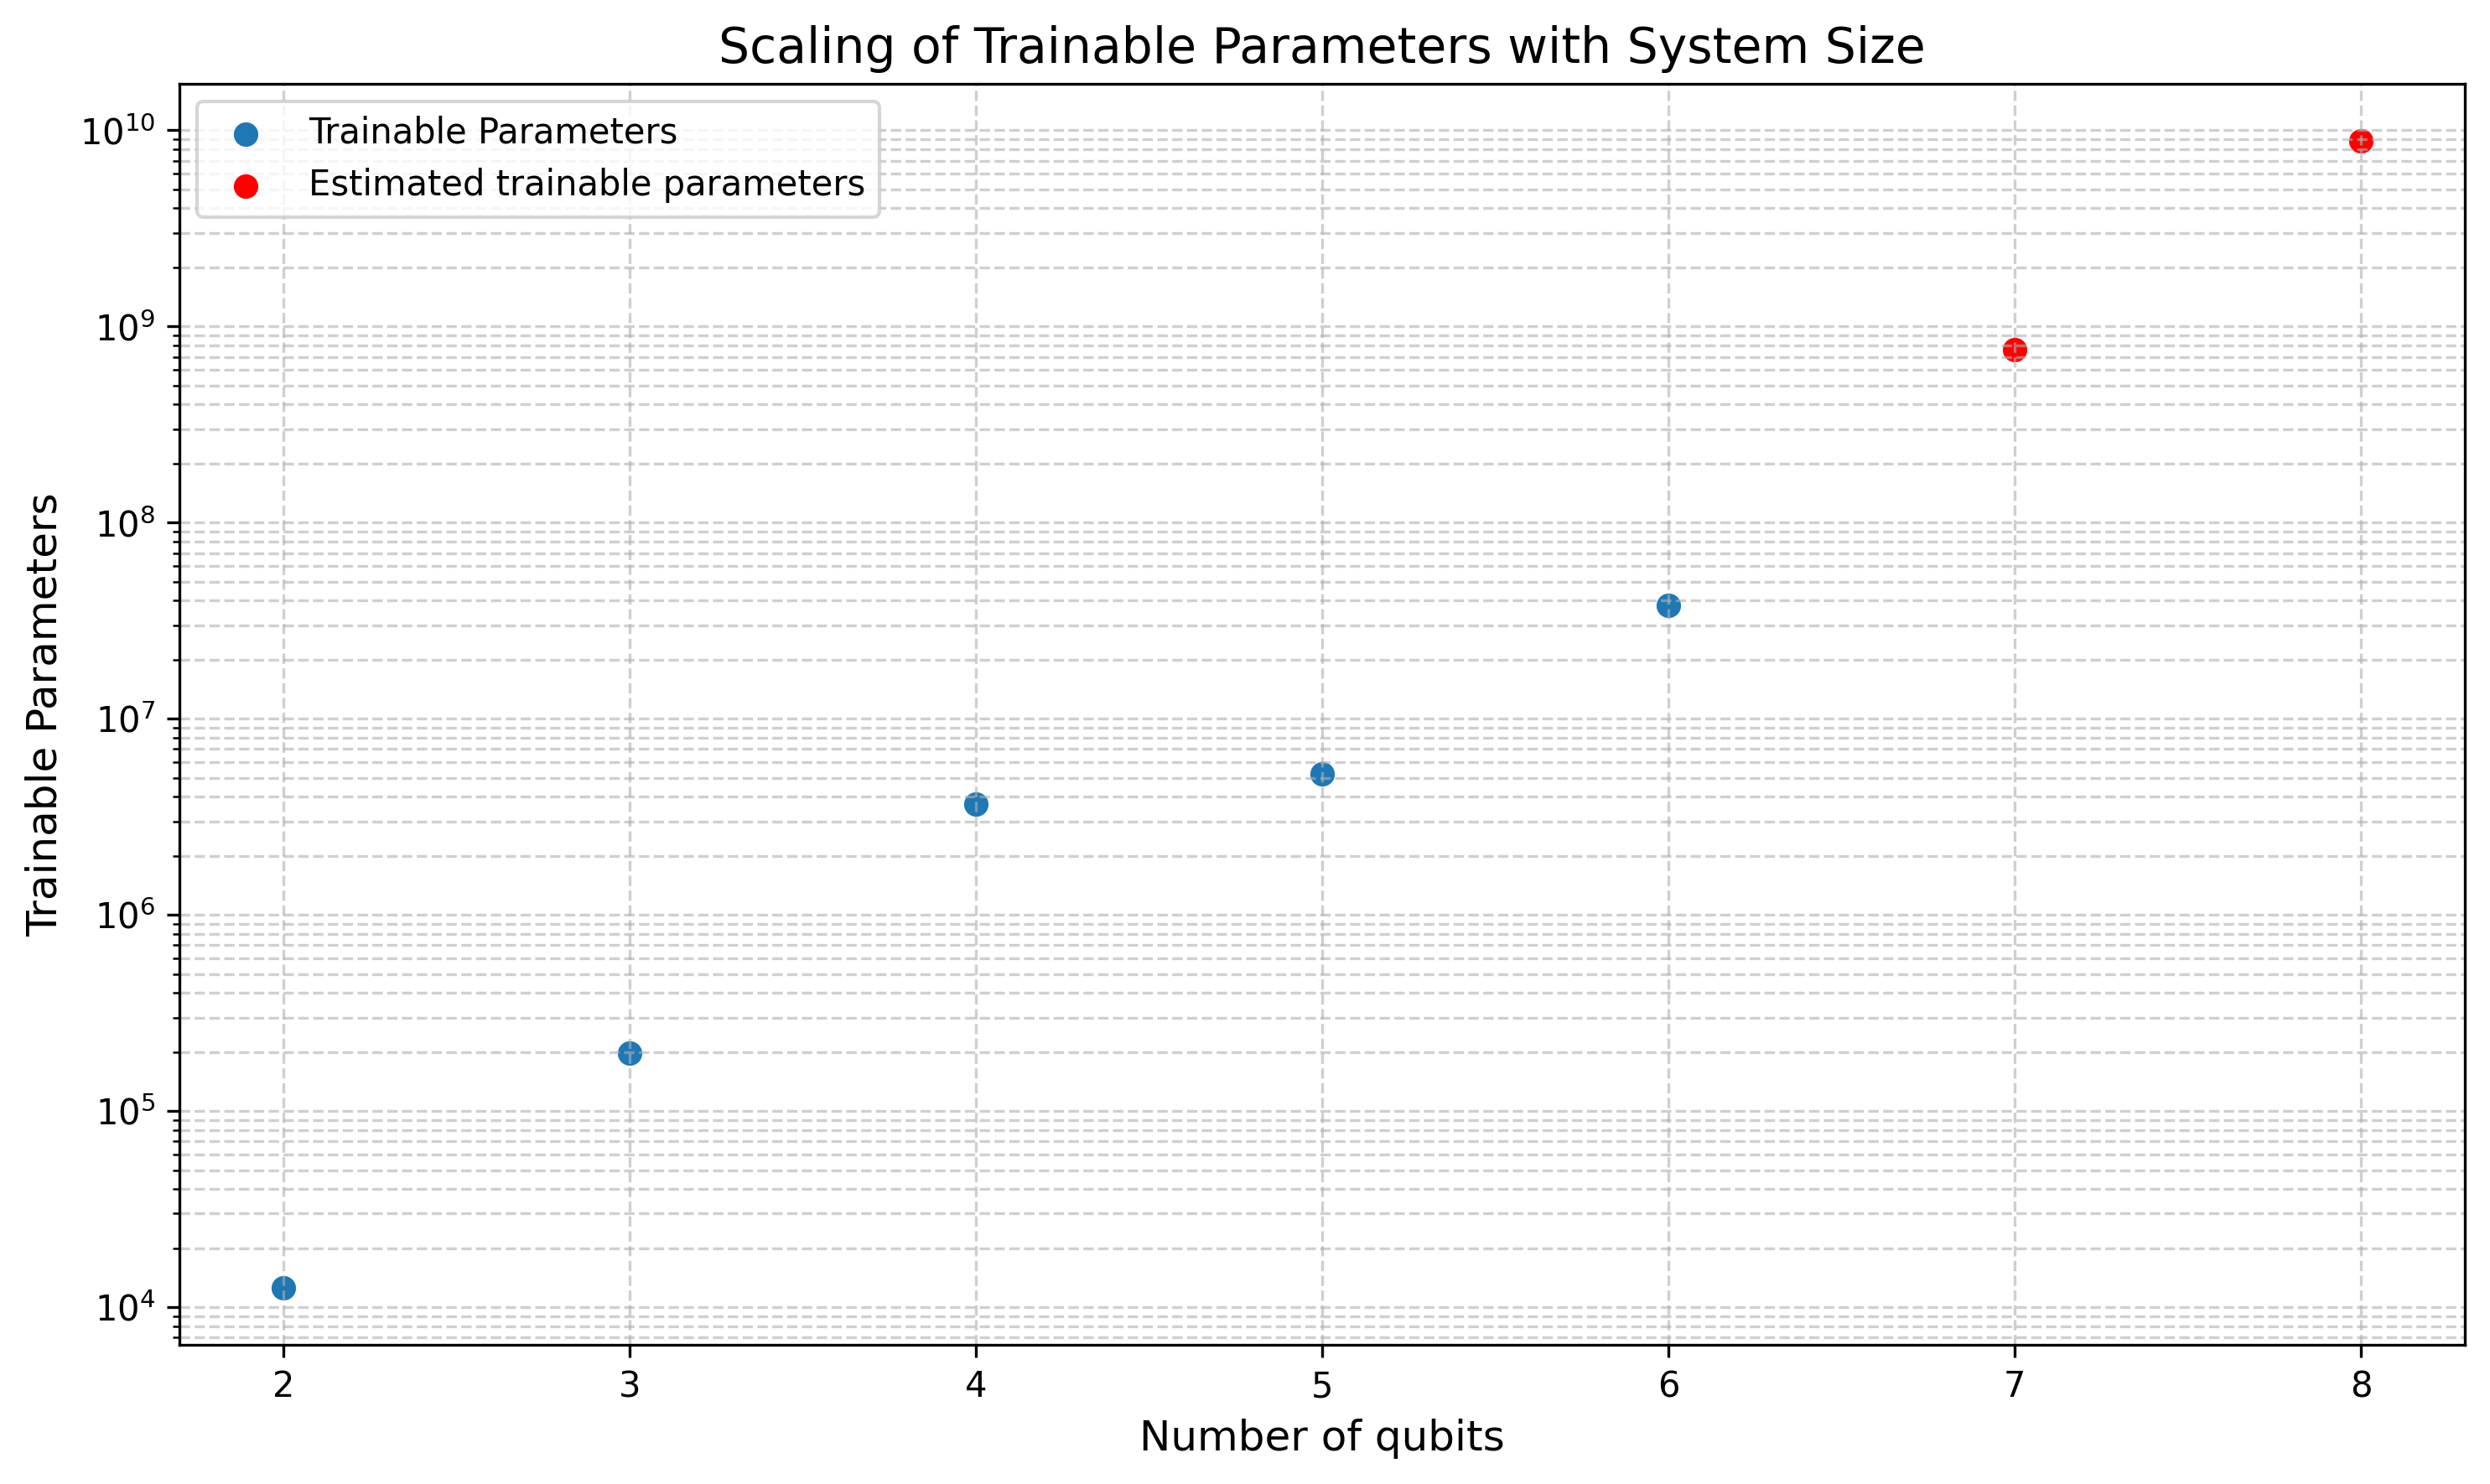

In [10]:
# ---------------------------------------------------------------------------------------- #
# Make the plot of the number of trainable parameters

qubits = np.arange(2, 9)
restricted_indices = [5, 6]
params = np.array([
    12576,           # 2 qubits
    197760,          # 3 qubits
    3674624,         # 4 qubits
    5248000,         # 5 qubits
    37763072,        # 6 qubits
    760000000,       # 7 qubits (estimado)
    8800000000       # 8 qubits (estimado)
])

# Make the plot
plt.figure(figsize=(10, 6), dpi=300)
plt.scatter(qubits[:5], params[:5], marker='o', label='Trainable Parameters')
plt.yscale('log')

# Marcar los puntos con Hamiltonianos restringidos
plt.scatter(np.array(qubits)[restricted_indices],
            np.array(params)[restricted_indices],
            color='red', label='Estimated trainable parameters')

# Etiquetas y estilos
plt.xlabel('Number of qubits', fontsize=12)
plt.ylabel('Trainable Parameters', fontsize=12)
plt.title('Scaling of Trainable Parameters with System Size', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig("figures/scaling_num-trainable-parameters.pdf", dpi = 300)
plt.show()
plt.close()

4. The plot thats shown the results over a statistical analysis for different quantum systems

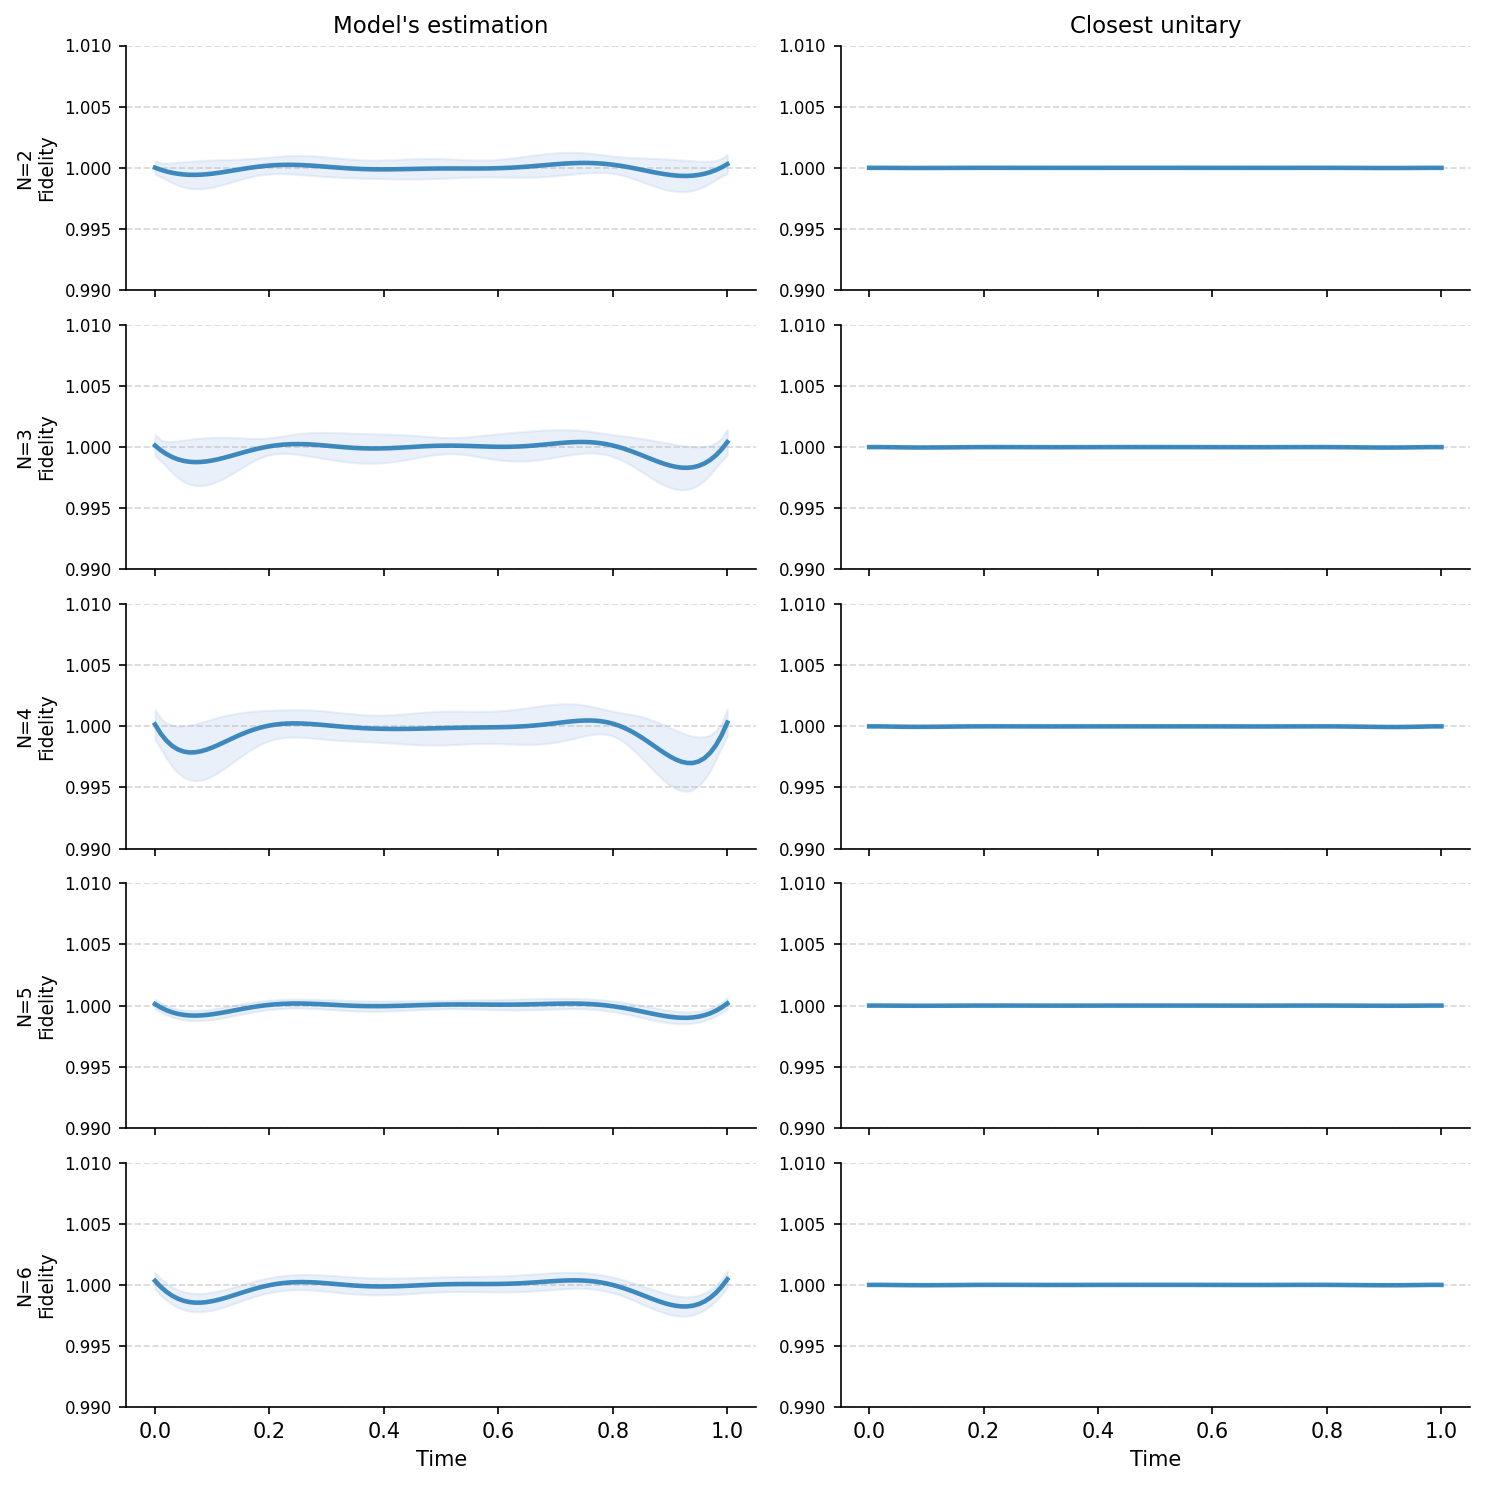

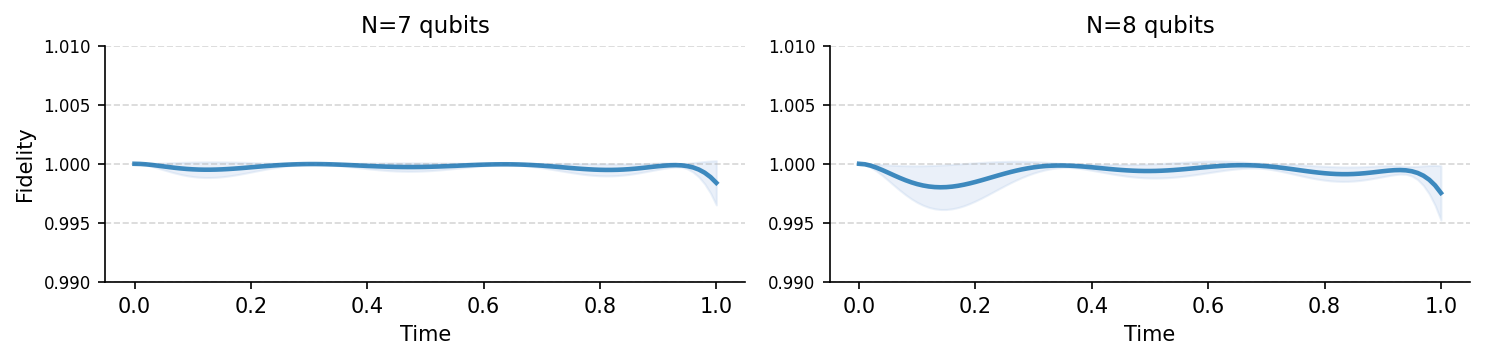

In [14]:
df = pd.read_pickle("dataframe/fidelity_statistic_results.pkl")

mean_color = "#1f77b4"
std_color  = "#aec7e8"

# ── Figure 1: N = 2 to 6 ─────────────────────────────────────────────────────
Ns_small   = [2, 3, 4, 5, 6]
cU_list    = [False, True]
col_titles = ["Model's estimation", "Closest unitary"]

fig, axes = plt.subplots(len(Ns_small), 2,
                         figsize=(10, 2 * len(Ns_small)),
                         sharex=True, dpi=150)

for row, N in enumerate(Ns_small):
    for col, cU_ in enumerate(cU_list):
        ax   = axes[row, col]
        data = df[(df["N"] == N) & (df["close_U"] == cU_)]["F"].to_numpy()
        data = np.vstack(data).astype(np.float32)

        data_mean = np.mean(data, axis=0)
        data_std  = np.std(data, axis=0)
        t         = np.linspace(0, 1, len(data_mean))

        ax.plot(t, data_mean, linewidth=2.2, color=mean_color, alpha=0.85)
        ax.fill_between(t, data_mean - data_std, data_mean + data_std,
                        alpha=0.25, color=std_color)

        if row == 0:
            ax.set_title(col_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(f"N={N}\nFidelity", fontsize=9)
        if row == len(Ns_small) - 1:
            ax.set_xlabel("Time", fontsize=10)

        ax.tick_params(axis='y', labelsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylim([0.99, 1.01])

fig.tight_layout(h_pad=0.8)
plt.savefig("figures/fidelity_statistic_plots_2to6.pdf", bbox_inches="tight")
plt.show()
plt.close()

# ── Figure 2: N = 7 and 8, model only, 1 row 2 columns ───────────────────────
Ns_large = [7, 8]

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True, dpi=150)

for col, N in enumerate(Ns_large):
    ax   = axes[col]
    data = df[(df["N"] == N) & (df["close_U"] == False)]["F"].to_numpy()
    data = np.vstack(data).astype(np.float32)

    data_mean = np.mean(data, axis=0)
    data_std  = np.std(data, axis=0)
    t         = np.linspace(0, 1, len(data_mean))

    ax.plot(t, data_mean, linewidth=2.2, color=mean_color, alpha=0.85)
    ax.fill_between(t, data_mean - data_std, data_mean + data_std,
                    alpha=0.25, color=std_color)

    ax.set_ylim([0.99, 1.01])
    ax.set_title(f"N={N} qubits", fontsize=11)
    ax.set_xlabel("Time", fontsize=10)
    if col == 0:
        ax.set_ylabel("Fidelity", fontsize=10)

    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.savefig("figures/fidelity_statistic_plots_7to8.pdf", bbox_inches="tight")
plt.show()
plt.close()